In [2]:
import anndata as ad
import squidpy as sq
import cellcharter as cc
import pandas as pd
import scanpy as sc
import scvi
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import liana as li
import geopandas as gpd
from matplotlib.widgets import LassoSelector
from shapely.geometry import Polygon
import ipympl 
%matplotlib widget
import matplotlib
import spatialdata as spd
from spatialdata.transformations import get_transformation # to get scale factors and offsets for shapes → image pixel mapping
from shapely.affinity import scale as shapely_scale, translate # shapes management
import geopandas as gpd # for handling shapes as geodataframes

/Users/janzules/miniforge3/envs/spatial_cpu_py311/lib/python3.11/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/Users/janzules/miniforge3/envs/spatial_cpu_py311/lib/python3.11/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution


# Data Prep

In [3]:
# Directories
project_dir = Path("/Users/janzules/Roselab/Spatial/CAR_T")
data_dir    = project_dir / "data"
results_dir = project_dir / "results"
figures_dir = project_dir / "figures"

In [4]:
# Files
hallmark_file  = project_dir / "code/references/Mouse_Hallmark.gmt"
zarr_file      = data_dir / "zarrFiles/CellCharterClusters"

## Loading Data

In [5]:
#Reading in files

sdata = spd.read_zarr(zarr_file)
adata = sdata.tables['segmentation_counts']


root_attr: omero
root_attr: version
root_attr: multiscales
datasets [{'path': '0', 'coordinateTransformations': [{'type': 'scale', 'scale': [1.0, 1.0, 1.0]}]}]
resolution: 0
 - shape ('c', 'y', 'x') = (3, 2645, 2706)
 - chunks =  ['3', '2645', '2706']
 - dtype = uint8
root_attr: omero
root_attr: version
root_attr: multiscales
root_attr: omero
root_attr: version
root_attr: multiscales
datasets [{'path': '0', 'coordinateTransformations': [{'type': 'scale', 'scale': [1.0, 1.0, 1.0]}]}]
resolution: 0
 - shape ('c', 'y', 'x') = (3, 2348, 2448)
 - chunks =  ['3', '2348', '2448']
 - dtype = uint8
root_attr: omero
root_attr: version
root_attr: multiscales
root_attr: omero
root_attr: version
root_attr: multiscales
datasets [{'path': '0', 'coordinateTransformations': [{'type': 'scale', 'scale': [1.0, 1.0, 1.0]}]}]
resolution: 0
 - shape ('c', 'y', 'x') = (3, 2445, 2505)
 - chunks =  ['3', '2445', '2505']
 - dtype = uint8
root_attr: omero
root_attr: version
root_attr: multiscales
root_attr: omero

# Functions

In [6]:
def read_gmt(gmt_path, min_genes=3, max_genes=5000):
    pathways = {}
    with open(gmt_path, "r", encoding="utf-8") as f:
        for line in f:
            parts = line.rstrip("\n").split("\t")
            if len(parts) < 3:
                continue
            name = parts[0].replace("HALLMARK_", "").lower().capitalize()
            genes = [g for g in parts[2:] if g]  # parts[1] is "description"
            if min_genes <= len(genes) <= max_genes:
                pathways[name] = genes
    return pathways

pathways_dict = read_gmt(hallmark_file)

In [7]:
# Scoring Pathways of interest

def pathway_scoring(adata, pathways_path, pathways_of_interest):
    # loading pathways
    pathways = read_gmt(pathways_path)
    
    # Chcking if I named the pathways correctly
    failed_pathways = []
    for pathway_name in pathways_of_interest:
        if pathway_name not in pathways:
            print(f"Warning: Pathway '{pathway_name}' not found in the provided pathways.")
            failed_pathways.append(pathway_name)
            continue
    
        #Scoring pathways
        genes = pathways[pathway_name]
        
        genes_in_data = [gene for gene in genes if gene in adata.var_names]
        if len(genes_in_data) < 10: # the lowest number of genes in these pathways is around 27
            print(f"Warning: Not enough genes from pathway '{pathway_name}' are present in the data for scoring.")
            failed_pathways.append(pathway_name)
            continue
        
        sc.tl.score_genes(adata, 
                          gene_list=genes_in_data, 
                          score_name=pathway_name)
        if failed_pathways:
            print(f"Failed to score the following pathways: {', '.join(failed_pathways)}")

def find_pathway_names(pathways, search_term: list):
    matches = [key for key in pathways.keys() if any(term.lower() in key.lower() for term in search_term)]
    return matches




In [8]:
# For a given tissue, get its transform dynamically

def get_tissue_transform(sdata, tissue_name):
    """Returns (scale, tx, ty) for this tissue's shapes → image pixel mapping."""
    shapes_key = f"{tissue_name}_cell_boundaries"
    image_key  = f"{tissue_name}_hires_tissue_image"
    cs = "downscale_to_hires"

    # Scale comes from the shapes transform (a Scale object)
    shapes_tf = get_transformation(sdata.shapes[shapes_key], get_all=True)[cs]
    scale = float(shapes_tf.scale[0])

    # tx, ty come from the image transform (a Sequence → Translation first)
    image_tf = get_transformation(sdata.images[image_key], get_all=True)[cs]
    translation = image_tf.transformations[0].translation  # (c, y, x)
    ty = float(translation[1])
    tx = float(translation[2])

    return scale, tx, ty


## Testing functions

# Scoring

In [9]:
pathways = ['Glycolysis', 'Interferon_alpha_response', 'Interferon_gamma_response']

pathway_scoring(adata, hallmark_file, pathways_of_interest=pathways)

# testing

## Visualizing pathways

In [15]:
from matplotlib.widgets import RectangleSelector
from matplotlib.path import Path as MplPath





def onselect(eclick, erelease):
    x0, x1 = sorted([eclick.xdata, erelease.xdata])
    y0, y1 = sorted([eclick.ydata, erelease.ydata])
    sel = (
        (coords_shared[:, 0] >= x0) & (coords_shared[:, 0] <= x1) &
        (coords_shared[:, 1] >= y0) & (coords_shared[:, 1] <= y1)
    )
    state["sel"][:] = sel
    status.set_text(f"Selected: {sel.sum()} cells")
    fig.canvas.draw_idle()

# rect = RectangleSelector(
#     ax, onselect,
#     button=[1], interactive=True, useblit=False,
#     props=dict(edgecolor="yellow", facecolor="none", linewidth=2)
# )


Showing 4779 / 19117 cells (top 25.0%, threshold=1.133)


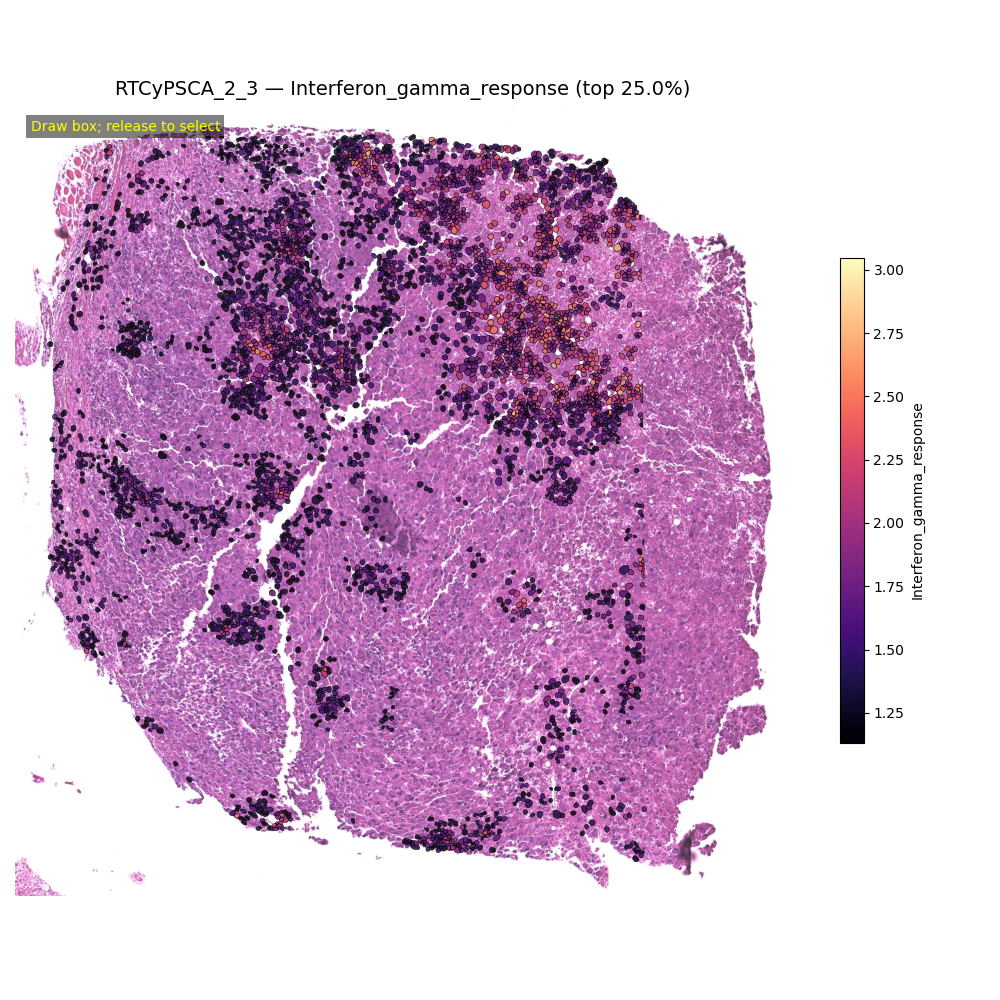

In [18]:
tissue_name   = "RTCyPSCA_2_3"
pathway_score = "Interferon_gamma_response"
cmap          = "magma"
top_quantile  = 0.25      # show only top 7.5% of scores
he_alpha      = 0.8     # H&E image transparency
shrink        = 1       # how much to shrink the polygons

image_key    = f"{tissue_name}_hires_tissue_image"
boundary_key = f"{tissue_name}_cell_boundaries"

image  = sdata.images[image_key].values  # (3, Y, X)
shapes = sdata.shapes[boundary_key].copy()

# -- Different shape conversions ---
#  Convex hull — smooths jagged polygons into a convex shape
# pixels in image space — tune this value
shapes["geometry"] = shapes["geometry"].convex_hull.buffer(-shrink)

# --- Scale factor and translation from the transforms ---
scale, tx, ty = get_tissue_transform(sdata, tissue_name)

# --- Apply scale to polygons ---
shapes["geometry"] = shapes["geometry"].apply(
    lambda geom: shapely_scale(geom, xfact=scale, yfact=scale, origin=(0, 0))
)

# --- Merge scores to shapes df ---

mask  = adata.obs["tissue"] == tissue_name
a_sub = adata[mask]
shapes = shapes.join(a_sub.obs[[pathway_score]], how="left")

state = {"sel": np.zeros(a_sub.n_obs, dtype=bool)}

# --- Centroids for this tissue in shared coordinate space ---
tissue_obs_index = a_sub.obs_names
raw_coords    = adata.obsm["spatial"][adata.obs["tissue"] == tissue_name]
coords_shared = raw_coords * scale   # → shared space (same as axes coords)


# --- Filter to top quantile only ---
threshold = shapes[pathway_score].quantile(1-top_quantile)
shapes_top = shapes[shapes[pathway_score] >= threshold].copy()
print(f"Showing {len(shapes_top)} / {len(shapes)} cells (top {top_quantile*100:.1f}%, threshold={threshold:.3f})")




# --- Plot ---
fig, ax = plt.subplots(figsize=(10, 10))

img_rgb = np.transpose(image, (1, 2, 0))
h, w = img_rgb.shape[:2]
ax.imshow(img_rgb, extent=[tx, tx + w, ty + h, ty], origin="upper", alpha=he_alpha)

shapes_top.plot(
    column=pathway_score,
    cmap=cmap,
    ax=ax,
    alpha=0.8,
    # - outline colors
    edgecolor="black",
    linewidth=0.5,
    legend=True,
    legend_kwds={"label": pathway_score, "shrink": 0.5}
)

ax.set_title(f"{tissue_name} — {pathway_score} (top {top_quantile*100:.1f}%)", fontsize=14)
ax.axis("off")
plt.tight_layout()

# --- Interactive selection ---

status = ax.text(
    0.02, 0.98, "Draw box; release to select",
    transform=ax.transAxes, va="top", color="yellow",
    bbox=dict(facecolor="black", alpha=0.5, pad=3, edgecolor="none")
)

rect = RectangleSelector(
    ax, onselect,
    button=[1], interactive=True, useblit=False,
    props=dict(edgecolor="yellow", facecolor="none", linewidth=2)
)

plt.show()


In [19]:
assert state["sel"].any(), "Draw a selection box first"

adata_sel = a_sub[state["sel"]].copy()
print(f"Selected {adata_sel.n_obs} cells")


Selected 1696 cells


In [20]:
adata_sel.obs['c2l_label_perm'].value_counts()

c2l_label_perm
Unknown        1442
Monocyte        119
Neutrophils     104
Erythrocyte      22
CAR_T_cell        5
Endothelial       2
Macrophage        1
NK_cell           1
Name: count, dtype: int64

In [ ]:
# for cell_type in adata_sel.obs["c2l_label_perm"].unique():
    
#     print(ct_count)
# # for cell_type in ct_count:
# #     if ct_count < 2:
# #         print(f"Skipping {cell_type} — only {ct_count} cell(s)")
# #         continue



In [38]:
valid_cell_types

CategoricalIndex(['Unknown', 'Neutrophils', 'CAR_T_cell', 'Monocyte',
                  'Erythrocyte', 'Macrophage', 'NK_cell'],
                 categories=['CAR_T_cell', 'Endothelial', 'Erythrocyte', 'Fibroblast', ..., 'Monocyte', 'NK_cell', 'Neutrophils', 'Unknown'], ordered=False, dtype='category', name='c2l_label_perm')

In [34]:
valid_cell_types

Index([False], dtype='bool', name='c2l_label_perm')

In [22]:
import gseapy as gp

databases = [
    "KEGG_2019_Mouse",
    "GO_Biological_Process_2023",
    "GO_Molecular_Function_2023",
]

# --- Removing low cell counts --- #
ct_counts = adata_sel.obs["c2l_label_perm"].value_counts()
valid_cell_types = ct_counts[ct_counts >= 2].index
adata_sel = adata_sel[adata_sel.obs["c2l_label_perm"].isin(valid_cell_types)]

sc.tl.rank_genes_groups(adata_sel, groupby="c2l_label_perm", method="wilcoxon")

ora_results = {}

for cell_type in adata_sel.obs["c2l_label_perm"].unique():
    

    markers = (
        sc.get.rank_genes_groups_df(adata_sel, group=cell_type)
        # .query("pvals_adj < 0.2 and logfoldchanges > 0.5")
        .query("pvals < 0.05 and logfoldchanges > 0.5")
        .head(200)["names"]
        .tolist()
    )

    if len(markers) < 3:
        print(f"Skipping {cell_type} — too few markers ({len(markers)})")
        continue

    print(f"Running ORA for {cell_type} ({len(markers)} markers)...")
    ora_results[cell_type] = gp.enrichr(
        gene_list=markers,
        gene_sets=databases,
        organism="mouse",
        outdir=None,
    ).results

# Summary
for ct, df in ora_results.items():
    sig = df[df["Adjusted P-value"] < 0.05].sort_values("Adjusted P-value")
    print(f"\n=== {ct} ({len(sig)} significant terms) ===")
    print(sig[["Gene_set", "Term", "Overlap", "Adjusted P-value"]]
          .head(10).to_string(index=False))


/Users/janzules/miniforge3/envs/spatial_cpu_py311/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:669: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.


Running ORA for Unknown (200 markers)...
Running ORA for Neutrophils (119 markers)...
Running ORA for Monocyte (23 markers)...
Running ORA for Erythrocyte (112 markers)...
Running ORA for Endothelial (163 markers)...
Running ORA for CAR_T_cell (110 markers)...

=== Unknown (67 significant terms) ===
                  Gene_set                                                  Term Overlap  Adjusted P-value
GO_Biological_Process_2023 Positive Regulation Of Dephosphorylation (GO:0035306)    6/29          0.000551
           KEGG_2019_Mouse                Fluid shear stress and atherosclerosis   8/143          0.004903
           KEGG_2019_Mouse                                GnRH signaling pathway    7/90          0.004903
           KEGG_2019_Mouse                                Long-term potentiation    6/67          0.004903
           KEGG_2019_Mouse                                         Axon guidance   9/180          0.004903
           KEGG_2019_Mouse                            Oxy

'NK_cell'

In [52]:
sc.get.rank_genes_groups_df(adata_sel, group="Neutrophils")

,names,scores,logfoldchanges,pvals,pvals_adj
0,Gbp2,5.578351,1.394122,2.428087e-08,0.000462
1,Serpina3g,4.681112,1.983649,2.853229e-06,0.017305
2,Cxcl9,4.661839,1.633423,3.133967e-06,0.017305
3,Zfp36,4.631050,1.746818,3.638161e-06,0.017305
4,Ly6a,4.110671,0.736221,3.945119e-05,0.125100
...,...,...,...,...,...
19021,Asph,-3.566411,-1.854270,3.619030e-04,0.388230
19022,Kpnb1,-3.604352,-2.390486,3.129327e-04,0.388230
19023,mt-Atp8,-3.678051,-0.270811,2.350227e-04,0.319396
19024,Pkig,-3.731265,-2.211654,1.905207e-04,0.319396


In [56]:
(
    sc.get.rank_genes_groups_df(adata_sel, group="Neutrophils")
    .query("pvals < 0.05 and logfoldchanges > 0.5")
    .head(200)["names"]
    .tolist()
)

['Gbp2',
 'Serpina3g',
 'Cxcl9',
 'Zfp36',
 'Ly6a',
 'Cebpb',
 'Irf1',
 'Iigp1',
 'Vmp1',
 'Icam1',
 'Ptgs2',
 'Mcl1',
 'Tyrobp',
 'Serpine2',
 'Aff1',
 'Acod1',
 'Gbp4',
 'Grem1',
 'Stat1',
 'Cd74',
 'Itm2a',
 'Irgm2',
 'Rab8b',
 'Cd52',
 'Cxcl10',
 'Cfb',
 'Ier3',
 'Spi1',
 'Ptprc',
 'Pycard',
 'Taok1',
 'Grina',
 'Stom',
 'Zfp36l2',
 'Cd53',
 'Mmp9',
 'Tnfrsf23',
 'Sell',
 'Stx11',
 'Rcn2',
 'Gpnmb',
 'Ccl2',
 'Il2rg',
 'Irf8',
 'Kcmf1',
 'Ifrd1',
 'Tlr2',
 'Irgm1',
 'Pla1a',
 'Itgb7',
 'Cybb',
 'H2-Eb1',
 'Sat1',
 'Enc1',
 'Lrp10',
 'Tapbp',
 'Il4ra',
 'Ddit3',
 'Pthlh',
 'H2-D1',
 'Crem',
 'Slfn2',
 'Rnf130',
 'Igfbp6',
 'Scyl1',
 'Gbp5',
 'H2-K1',
 'Itga5',
 'Fgl2',
 'Sdf2l1',
 'Jak2',
 'App',
 'Hist1h2bc',
 'Slpi',
 'Tmem140',
 'Pdia4',
 'Nfkbia',
 'Rtf2',
 'Plxnb2',
 'C3',
 'Slfn1',
 'Parp14',
 'Hilpda',
 'Plek',
 'Ccl8',
 'Dusp1',
 'Arl6ip5',
 'Sgk1',
 'Irak2',
 'Ccr5',
 'Rhob',
 'Rlim',
 'Sgms2',
 'Rab8a',
 'Ubp1',
 'Ppp2cb',
 'Eif3d',
 'Il1b',
 'Hck',
 'H13',
 'Gtf2f1',
 'Tn

# Miscellaneous

## Metadata

In [20]:
list(sdata.images.keys())

['CyPSCA_1_1_hires_tissue_image',
 'CyPSCA_1_2_hires_tissue_image',
 'CyPSCA_2_4_hires_tissue_image',
 'CyT72_1_2_hires_tissue_image',
 'CyT72_1_4_hires_tissue_image',
 'CyT72_2_3_hires_tissue_image',
 'NoTx_1_4_hires_tissue_image',
 'NoTx_2_2_hires_tissue_image',
 'NoTx_2_4_hires_tissue_image',
 'RTCyPSCA_1_3_hires_tissue_image',
 'RTCyPSCA_1_4_hires_tissue_image',
 'RTCyPSCA_2_3_hires_tissue_image',
 'RTCyPSCA_2_4_hires_tissue_image',
 'RTCyT72_1_1_hires_tissue_image',
 'RTCyT72_2_1_hires_tissue_image',
 'RTCyT72_2_4_hires_tissue_image']

In [24]:
from spatialdata.transformations import get_transformation

for image_key in sdata.images:
    transforms = get_transformation(sdata.images[image_key], get_all=True)
    for cs, t in transforms.items():
        matrix = t.to_affine_matrix(input_axes=('x', 'y'), output_axes=('x', 'y'))
        x = matrix[0, 2]
        y = matrix[1, 2]
        print(f"{image_key} [{cs}]: x={x:.2f}, y={y:.2f}")
        

CyPSCA_1_1_hires_tissue_image [downscale_to_hires]: x=210.00, y=125.00
CyPSCA_1_2_hires_tissue_image [downscale_to_hires]: x=1205.00, y=304.00
CyPSCA_2_4_hires_tissue_image [downscale_to_hires]: x=3274.00, y=2978.00
CyT72_1_2_hires_tissue_image [downscale_to_hires]: x=156.00, y=582.00
CyT72_1_4_hires_tissue_image [downscale_to_hires]: x=858.00, y=2888.00
CyT72_2_3_hires_tissue_image [downscale_to_hires]: x=140.00, y=473.00
NoTx_1_4_hires_tissue_image [downscale_to_hires]: x=415.00, y=3031.00
NoTx_2_2_hires_tissue_image [downscale_to_hires]: x=299.00, y=2879.00
NoTx_2_4_hires_tissue_image [downscale_to_hires]: x=212.00, y=2729.00
RTCyPSCA_1_3_hires_tissue_image [downscale_to_hires]: x=2419.00, y=542.00
RTCyPSCA_1_4_hires_tissue_image [downscale_to_hires]: x=2909.00, y=218.00
RTCyPSCA_2_3_hires_tissue_image [downscale_to_hires]: x=2854.00, y=362.00
RTCyPSCA_2_4_hires_tissue_image [downscale_to_hires]: x=3116.00, y=1075.00
RTCyT72_1_1_hires_tissue_image [downscale_to_hires]: x=2739.00, y=

In [9]:
sdata.tables['segmentation_counts'].obsm['spatial'].shape

(425859, 2)